# Experiment 3: Robustness to the affordance matrix

In [8]:
import json
from pathlib import Path

import numpy as np

import analysis
import plots
from affordance_matrices import ACTION_LABELS, AFFORDANCE_MATRIX_VARIANTS, FEATURE_LABELS
from experiment_config import (
    DEVELOPMENTAL_PROFILES, MATRIX_TASKS, MATRIX_TRIALS_PER_SEED_SET,
    PROFILE_NAMES, SEED_SETS,
)

In [ ]:
RESULTS = Path("results")
VARIANTS = list(AFFORDANCE_MATRIX_VARIANTS)
TASK_NAMES = list(MATRIX_TASKS)

print(
    f"{len(VARIANTS)} matrices x {len(PROFILE_NAMES)} profiles x {len(TASK_NAMES)} tasks "
    f"x {len(SEED_SETS)} batches x {MATRIX_TRIALS_PER_SEED_SET} trials"
)
for name, task in MATRIX_TASKS.items():
    print(
        f"  {name:16s} goal=({task.goal_x:.2f}, {task.goal_angle:.2f} rad)  "
        f"object {task.obj_width:.2f} x {task.obj_height:.2f}  limit {task.max_timesteps}"
    )

5 matrices x 4 profiles x 6 tasks x 5 batches x 20 trials
  very_easy        goal=(0.30, 0.53 rad)  object 0.40 x 0.40  limit 120
  easy             goal=(0.35, 0.60 rad)  object 0.30 x 0.45  limit 120
  medium_rotated   goal=(0.50, 1.20 rad)  object 0.30 x 0.60  limit 120
  very_hard        goal=(0.95, 2.60 rad)  object 0.60 x 0.30  limit 170
  extreme          goal=(1.10, 3.14 rad)  object 0.60 x 0.30  limit 190
  time_pressured   goal=(1.10, 3.14 rad)  object 0.60 x 0.30  limit 62


## Matrix definitions

/var/folders/xg/33gspqg50c33v_knz9v7dzm80000gn/T/ipykernel_74563/4128347223.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plots.plot_affordance_matrices(AFFORDANCE_MATRIX_VARIANTS, FEATURE_LABELS, ACTION_LABELS).show()


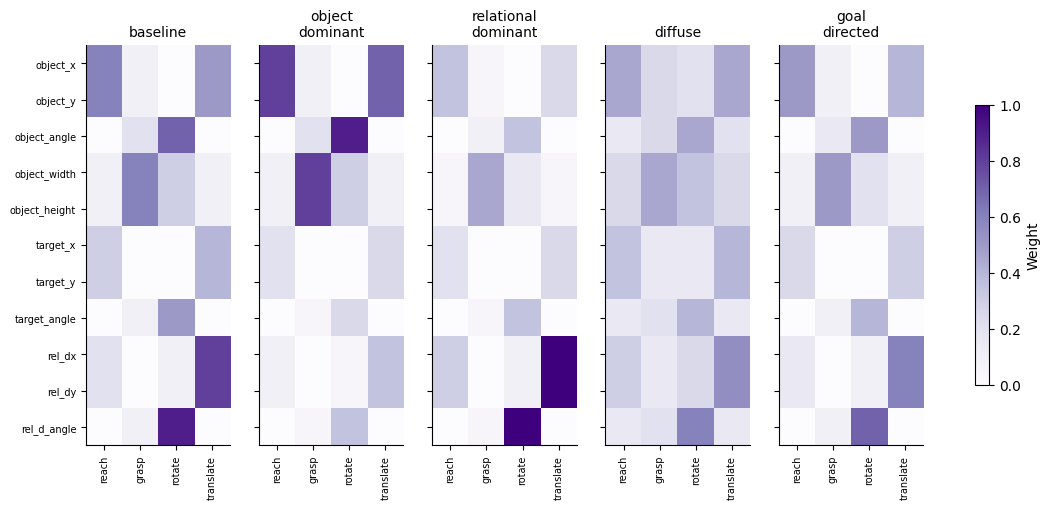

In [2]:
plots.plot_affordance_matrices(AFFORDANCE_MATRIX_VARIANTS, FEATURE_LABELS, ACTION_LABELS).show()

## How much does the per-trial jitter blur the variants?

In [ ]:
with open(RESULTS / "experiment_3.json") as handle:
    exp3 = json.load(handle)

print(f"{'profile':>8s}{'coupling':>10s}{'mean separation':>18s}{'E|jitter|':>11s}{'ratio':>8s}")

for profile in PROFILE_NAMES:
    row = exp3["jitter_vs_separation"][profile]
    print(f"{profile:>8s}{row['coupling']:10.2f}{row['mean_variant_separation']:18.4f}"
          f"{row['expected_absolute_jitter']:11.4f}{row['jitter_to_separation_ratio']:8.2f}")

any_row = exp3["jitter_vs_separation"][PROFILE_NAMES[0]]

print(f"\n{any_row['zero_entry_fraction']:.0%} of matrix entries are exactly zero; clipping at zero")
print(f"gives them a positive expected offset of {any_row['clipping_bias_on_zero_entries']:.4f}.")

 profile  coupling   mean separation  E|jitter|   ratio
       A      0.25            0.0284     0.0239    0.84
       B      0.40            0.0454     0.0239    0.53
       C      0.60            0.0680     0.0239    0.35
       D      0.85            0.0964     0.0239    0.25

25% of matrix entries are exactly zero; clipping at zero
gives them a positive expected offset of 0.0120.


## Which cells can express a matrix effect?

A cell at floor or ceiling cannot, whatever the truth about the mapping.

In [4]:
informative = exp3["informative_cells"]
print(f"{'':10s}" + "".join(f"{name[:13]:>15s}" for name in TASK_NAMES))

for profile in PROFILE_NAMES:
    print(f"{profile:10s}" + "".join(
        f"{('yes' if informative[profile][name] else '-'):>15s}" for name in TASK_NAMES))

count = sum(int(informative[p][t]) for p in PROFILE_NAMES for t in TASK_NAMES)
print(f"\n{count} of {len(PROFILE_NAMES) * len(TASK_NAMES)} cells are informative; "
      f"every profile has at least one.")

                very_easy           easy  medium_rotate      very_hard        extreme  time_pressure
A                     yes            yes              -              -              -              -
B                       -            yes            yes              -              -              -
C                       -              -              -            yes            yes              -
D                       -              -              -              -              -            yes

7 of 24 cells are informative; every profile has at least one.


## Results

/var/folders/xg/33gspqg50c33v_knz9v7dzm80000gn/T/ipykernel_74563/2890052639.py:1: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plots.plot_matrix_by_profile_task(exp3["cells"], PROFILE_NAMES, TASK_NAMES, VARIANTS).show()


Success rate by profile, task and matrix variant:

Profile A
  task                  baseline  object_domin  relational_d       diffuse  goal_directe
  very_easy                 0.67          0.55          0.47          0.54          0.51
  easy                      0.27          0.27          0.28          0.24          0.23
  medium_rotated *          0.03          0.07          0.07          0.01          0.05
  very_hard      *          0.00          0.00          0.00          0.00          0.00
  extreme        *          0.00          0.00          0.00          0.00          0.00
  time_pressured *          0.00          0.00          0.00          0.00          0.00

Profile B
  task                  baseline  object_domin  relational_d       diffuse  goal_directe
  very_easy      *          1.00          0.99          0.99          0.99          1.00
  easy                      0.84          0.85          0.91          0.83          0.87
  medium_rotated            0.42      

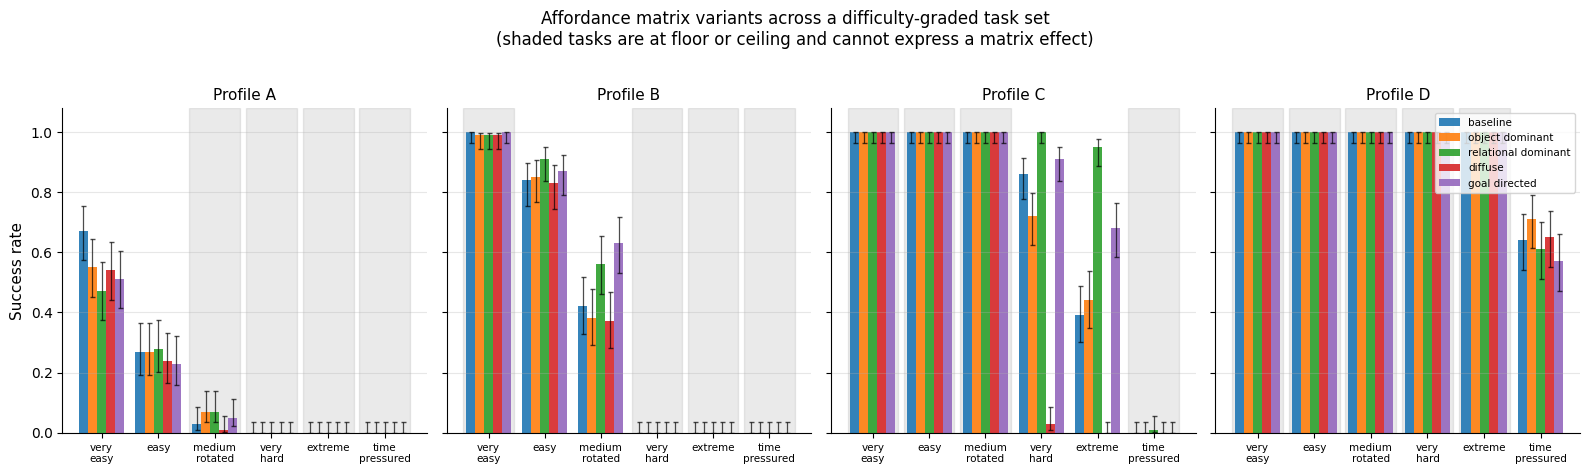

In [5]:
plots.plot_matrix_by_profile_task(exp3["cells"], PROFILE_NAMES, TASK_NAMES, VARIANTS).show()

print("Success rate by profile, task and matrix variant:")

for profile in PROFILE_NAMES:
    print(f"\nProfile {profile}")
    print(f"  {'task':16s}" + "".join(f"{v[:12]:>14s}" for v in VARIANTS))
    for task in TASK_NAMES:
        marker = " " if informative[profile][task] else "*"
        print(f"  {task:15s}{marker}" + "".join(
            f"{exp3['cells'][profile][task][v]['success_rate']:14.2f}" for v in VARIANTS))
        
print("\n* cell at floor or ceiling: no matrix effect could be expressed here.")

## Best vs worst matrix contrast

Reported as counts as well as proportions

In [6]:
print("{:>8s} {:16s}{:>22s}{:>22s}{:>26s}".format(
    "profile", "task", "best", "worst", "difference"))

for profile in PROFILE_NAMES:
    for task in TASK_NAMES:
        if not informative[profile][task]:
            continue

        row = exp3["matrix_contrasts"][profile][task]
        best = "{} {}/{}".format(row["best"][:12], row["best_successes"], row["best_n"])
        worst = "{} {}/{}".format(row["worst"][:12], row["worst_successes"], row["worst_n"])
        difference = "{:+.3f} [{:+.3f}, {:+.3f}]".format(
            row["difference"], row["ci_low"], row["ci_high"])
        
        print("{:>8s} {:16s}{:>22s}{:>22s}{:>26s}".format(
            profile, task, best, worst, difference))

detected = [(p, t) for p in PROFILE_NAMES for t in TASK_NAMES
            if informative[p][t] and exp3["matrix_contrasts"][p][t]["excludes_zero"]]

print(f"\nCells where the best-worst interval excludes zero: {len(detected)} "
      f"of {sum(int(informative[p][t]) for p in PROFILE_NAMES for t in TASK_NAMES)} informative cells")

for profile, task in detected:
    print(f"  {profile} / {task}")

 profile task                              best                 worst                difference
       A very_easy              baseline 67/100   relational_d 47/100   +0.200 [+0.066, +0.334]
       A easy               relational_d 28/100   goal_directe 23/100   +0.050 [-0.071, +0.171]
       B easy               relational_d 91/100        diffuse 83/100   +0.080 [-0.013, +0.173]
       B medium_rotated     goal_directe 63/100        diffuse 37/100   +0.260 [+0.126, +0.394]
       C very_hard         relational_d 100/100         diffuse 3/100   +0.970 [+0.937, +1.003]
       C extreme            relational_d 95/100         diffuse 0/100   +0.950 [+0.907, +0.993]
       D time_pressured     object_domin 71/100   goal_directe 57/100   +0.140 [+0.008, +0.272]

Cells where the best-worst interval excludes zero: 5 of 7 informative cells
  A / very_easy
  B / medium_rotated
  C / very_hard
  C / extreme
  D / time_pressured


## Is the profile ordering preserved?

In [7]:
preserved = exp3["ordering_preserved"]
failures = [key for key, value in preserved.items() if not value]

print(f"ordering A <= B <= C <= D preserved in {sum(preserved.values())} "
      f"of {len(preserved)} (task, variant) combinations")

for key in failures:
    print("  not preserved:", key)

ordering A <= B <= C <= D preserved in 30 of 30 (task, variant) combinations
